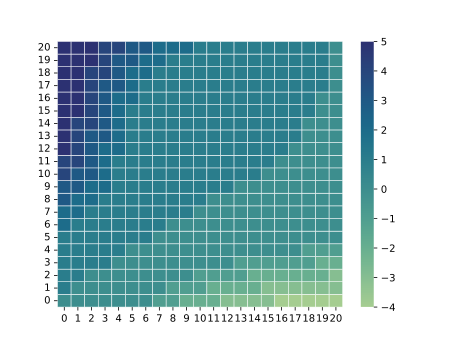

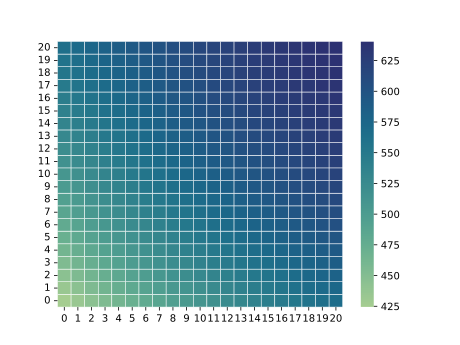

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
import sys
from IPython.display import SVG, display

# Maximum number of bikes that can be parked at each location
MAX_BIKES = 20

# Rental reward per bike rented out (in INR)
RENT_REWARD = 10

# Cost to move a bike between locations (in INR)
MOVE_COST = -2

# Maximum number of bikes that can be moved between locations per night
MAX_MOVE_BIKES = 5

# Discount rate applied to future rewards
DISCOUNT_RATE = 0.9

# Custom Poisson Class for Distribution Calculations
class PoissonDistribution:
    def __init__(self, _lambda, epsilon=0.01):
        self._lambda = _lambda
        self.alpha = 0
        self.vals = {}
        self._initialize_pmf(epsilon)

    def _initialize_pmf(self, epsilon):
        summer = 0
        state = 1
        while state == 1:
            temp = poisson.pmf(self.alpha, self._lambda)
            if temp <= epsilon:
                self.alpha += 1
            else:
                self.vals[self.alpha] = temp
                summer += temp
                self.beta = self.alpha + 1
                state = 2
        while state == 2:
            temp = poisson.pmf(self.beta, self._lambda)
            if temp > epsilon:
                self.vals[self.beta] = temp
                summer += temp
                self.beta += 1
            else:
                break

        # Normalize pmf values
        added_val = (1 - summer) / (self.beta - self.alpha)
        for key in self.vals:
            self.vals[key] += added_val

    def f(self, n):
        return self.vals.get(n, 0)

# Location Class Definition
class Location:
    def __init__(self, request_lambda, return_lambda):
        self.request_lambda = request_lambda
        self.return_lambda = return_lambda
        self.poisson_request = PoissonDistribution(request_lambda)
        self.poisson_return = PoissonDistribution(return_lambda)

# Location Initialization
A = Location(3, 3)
B = Location(4, 2)

# Value and Policy Matrices Initialization
value = np.zeros((MAX_BIKES + 1, MAX_BIKES + 1))
policy = np.zeros_like(value, dtype=int)

# Functions for State Transition and Rewards
def apply_action(state, action):
    """Applies the action (bike transfer) to the current state."""
    new_state_A = max(min(state[0] - action, MAX_BIKES), 0)
    new_state_B = max(min(state[1] + action, MAX_BIKES), 0)
    return [new_state_A, new_state_B]

def expected_reward(state, action):
    """Calculates the expected reward for a given state and action."""
    reward = 0
    new_state = apply_action(state, action)

    # Reward for moving bikes
    if action <= 0:
        reward += MOVE_COST * abs(action)
    else:
        reward += MOVE_COST * (action - 1)

    # Compute reward for bike rentals and transitions
    for A_req in range(A.poisson_request.alpha, A.poisson_request.beta):
        for B_req in range(B.poisson_request.alpha, B.poisson_request.beta):
            for A_ret in range(A.poisson_return.alpha, A.poisson_return.beta):
                for B_ret in range(B.poisson_return.alpha, B.poisson_return.beta):
                    zeta = (
                        A.poisson_request.f(A_req) *
                        B.poisson_request.f(B_req) *
                        A.poisson_return.f(A_ret) *
                        B.poisson_return.f(B_ret)
                    )
                    valid_requests_A = min(new_state[0], A_req)
                    valid_requests_B = min(new_state[1], B_req)
                    reward_for_rentals = (valid_requests_A + valid_requests_B) * RENT_REWARD

                    # Next state after rentals and returns
                    next_state = [
                        max(min(new_state[0] - valid_requests_A + A_ret, MAX_BIKES), 0),
                        max(min(new_state[1] - valid_requests_B + B_ret, MAX_BIKES), 0)
                    ]

                    # Bellman's equation
                    reward += zeta * (reward_for_rentals + DISCOUNT_RATE * value[next_state[0], next_state[1]])

    return reward

def policy_evaluation():
    global value

    # here policy_evaluation has a static variable epsilon whose value decreases over time
    epsilon = policy_evaluation.epsilon

    policy_evaluation.epsilon /= 10

    while(1):
        delta = 0

        for i in range(value.shape[0]):
            for j in range(value.shape[1]):
                # value[i][j] denotes the value of the state [i,j]

                old_val = value[i][j]
                value[i][j] = expected_reward([i,j], policy[i][j])

                delta = max(delta, abs(value[i][j] - old_val))

        if delta < epsilon:
            break

# initial value of epsilon
policy_evaluation.epsilon = 50

def policy_improvement():
    global policy

    policy_stable = True
    for i in range(value.shape[0]):
        for j in range(value.shape[1]):
            old_action = policy[i][j]

            max_act_val = None
            max_act = None

            tau_12 = min(i, 5)  # if I have say 3 bikes at the first location, then I can at most move 3 from 1 to 2
            tau_21 = -min(j, 5) # if I have say 2 bikes at the second location, then I can at most move 2 from 2 to 1

            for act in range(tau_21, tau_12 + 1):
                sigma = expected_reward([i,j], act)
                if max_act_val is None:
                    max_act_val = sigma
                    max_act = act
                elif max_act_val < sigma:
                    max_act_val = sigma
                    max_act = act

            policy[i][j] = max_act

            if old_action != policy[i][j]:
                policy_stable = False

    return policy_stable

# Visualization: Saving Policy and Value Functions
def save_policy():
    save_policy.counter += 1
    ax = sns.heatmap(policy, linewidth=0.5, cmap="crest")
    ax.invert_yaxis()
    plt.savefig(f'policy{save_policy.counter}.svg')
    plt.close()

def save_value():
    save_value.counter += 1
    ax = sns.heatmap(value, linewidth=0.5, cmap="crest")
    ax.invert_yaxis()
    plt.savefig(f'value{save_value.counter}.svg')
    plt.close()

save_policy.counter = 0
save_value.counter = 0

# Main Loop for Policy Iteration
while True:
    policy_evaluation()
    stable = policy_improvement()
    save_value()
    save_policy()
    if stable:
        break

# Display Final Policy and Value
display(SVG(f'policy{save_policy.counter}.svg'))
display(SVG(f'value{save_value.counter}.svg'))

